In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [ ]:
path_gla_station_info = "data/validation/glacier-station/glacier_station_info.gpkg" 
path_hma_extent = "data/hma-extent/HMA/hma_gtng_202307_subregions.gpkg"

In [3]:
hma = gpd.read_file(path_hma_extent)
gla_info_gdf = gpd.read_file(path_gla_station_info)
gla_show_gdf = gla_info_gdf.drop_duplicates(subset=['geometry']) # 每个实测脚点只显示一个（实测日期不同但位置相同）
gla_show_gdf

,class,geometry
0,Clean_Ice,MULTIPOINT (91.06953 33.49237)
1,Clean_Ice,MULTIPOINT (91.56214 33.42567)
2,Clean_Ice,MULTIPOINT (92.09571 33.09336)
3,Clean_Ice,MULTIPOINT (91.16665 33.26771)
4,Clean_Ice,MULTIPOINT (89.15524 33.88084)
...,...,...
849,Water,MULTIPOINT (86.95183 27.84074)
850,Water,MULTIPOINT (86.91127 27.79336)
851,Water,MULTIPOINT (87.76023 27.93077)
852,Water,MULTIPOINT (88.40356 27.99677)


In [4]:
lon_center = (gla_info_gdf.bounds.minx + gla_info_gdf.bounds.maxx) / 2
lat_center = (gla_info_gdf.bounds.miny + gla_info_gdf.bounds.maxy) / 2

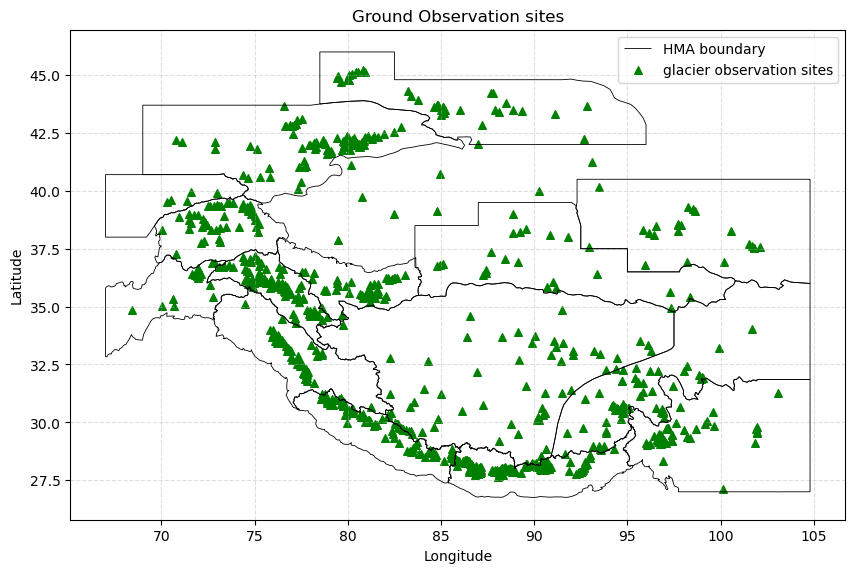

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
hma.boundary.plot(ax=ax, edgecolor="black", linewidth=0.6, label="HMA boundary")
ax.scatter(
    lon_center, lat_center,
    marker="^", s=30, color="green",
    label="glacier observation sites")
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("Ground Observation sites")
fig.savefig("figures/validation/ground_station_loc.png", bbox_inches='tight', dpi=200)